In [61]:
#there are some bugs in normalize.  we need to use the first STD and MEAN on test data 

#it has been corrected ,and the SquMean_error decreased from 653.85 to 591.58

In [2]:
import numpy as np
import pandas as pd

# 设置随机种子
np.random.seed(42)

# 生成200个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})


In [3]:
data_train=data.sample(frac=0.67)
data_test=data.sample(frac=0.33)

In [4]:
data_train.head()

,area,bedrooms,age,location,price
57,79.397429,3,6.387858,3.683271,170.776031
208,50.759238,3,2.872395,8.378941,191.474722
96,128.409924,3,3.469336,9.455086,230.737778
258,135.509176,3,6.536873,4.035025,215.947937
229,144.670794,2,17.655975,10.000000,230.845068


In [5]:
import numpy as np
import pandas as pd


In [6]:
#get ready

In [35]:
#normalize
Mean=data_train.mean(axis=0)
Std=data_train.std(axis=0)
data_normalized=(data_train-Mean)/Std
data_normalized.head()

,area,bedrooms,age,location,price
57,-1.059461,0.222235,-0.401316,-1.337162,-1.027266
208,-1.706539,0.222235,-0.755096,1.083131,-0.593884
96,0.047971,0.222235,-0.695023,1.637809,0.228192
258,0.208378,0.222235,-0.386320,-1.155857,-0.081473
229,0.415384,-0.787240,0.732656,1.918675,0.230438


In [8]:
#似乎与标准化也有关系，正常的标准化做的太离谱，s形状，但我这里不要S啊。/max /mean都试了
#正常的标准化0-1之间(x-x.min())/(x.max()-x.min())也不行

In [10]:
rng=np.random.default_rng(17)
primary_parameter={'power1':rng.random((4,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
print(primary_parameter)

{'power1': array([[0.08450748, 0.01609731, 0.05577445, 0.03680799, 0.0214942 ,
        0.0385824 , 0.04281645],
       [0.06113431, 0.07363859, 0.00152897, 0.02540409, 0.06041459,
        0.00837367, 0.09977637],
       [0.08323461, 0.00367774, 0.05675398, 0.06093401, 0.00069266,
        0.01790839, 0.01649222],
       [0.04619579, 0.05670036, 0.04519092, 0.09197757, 0.08149242,
        0.04011661, 0.02031616]]), 'threshold1': array([0.03583255, 0.0862035 , 0.03488156, 0.09910656, 0.05657688,
       0.02368459, 0.06586973]), 'power2': array([0.06602265, 0.05146076, 0.0279093 , 0.06299182, 0.04791908,
       0.06532888, 0.05422403]), 'threshold2': array([0.01212111])}


In [11]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [12]:
def get_loss(y,y_hat):
    return 1/2*pow((y_hat-y),2)

In [13]:
def upgrade_parameter(y,y_hat,x,level_1_to_2,\
              primary_parameter,alph=1):
    
    
    g=y_hat-y
    delta_power2=-alph*g*level_1_to_2
    delta_threshold2=-alph*g

    e=level_1_to_2*(1-level_1_to_2)*primary_parameter['power2']*g    #对后两项，我这里只是一维的输出，power2是1*7的
    delta_power1=-alph*x.reshape(-1,1)@e.reshape(1,-1)    #e,xi都是向量，最后会做成一个4*7的
    delta_threshold1=-alph*(-e)

    primary_parameter['power2']+=delta_power2
    primary_parameter['threshold2']+=delta_threshold2
    primary_parameter['power1']+=delta_power1
    primary_parameter['threshold1']+=delta_threshold1

    return primary_parameter


In [14]:
def standard_BP(data,primary_parameter,turn):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2+primary_parameter['threshold2'][0]    #why ?  #because array([1]) is not array(1)

    if turn%200==0:
        print(get_loss(y,y_hat))
    
    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter    

In [15]:
for j in range(10):
    for i in range(len(data_train)):
        primary_parameter=\
        standard_BP(data_normalized.iloc[i],primary_parameter,i)
print(primary_parameter)
        

0.7325622776090035
0.09907994725232522
0.052210131799434685
0.0037814111577966236
0.0072044468362363855
0.00387462699982299
0.00639655103342982
0.004008622560065271
0.005871666880880379
0.004145875847066938
0.005488158159426915
0.004312404631906671
0.005195461810440417
0.004530448674688874
0.004970211348180806
0.004821713068161563
0.004800718959642164
0.005209633771292087
0.004678585905380998
0.005718140830846943
{'power1': array([[ 1.24125373, -0.15417349, -0.74867775,  0.72507846,  0.33553223,
         0.37225678,  0.48401874],
       [ 0.30139179, -0.0629387 , -0.65571138,  0.32302506,  0.29524623,
         0.24330869,  0.4020584 ],
       [ 0.04036153,  0.03927838,  0.3309305 , -0.22981466, -0.16376333,
        -0.15126181, -0.21947938],
       [ 0.18311615,  0.0569691 , -0.09695378,  0.54740683,  0.32085288,
         0.30063393,  0.36431226]]), 'threshold1': array([-0.11667069,  0.46839942,  0.58989536,  0.28624918,  0.43234594,
        0.41113599,  0.38632947]), 'power2': array([

In [37]:
#the train has finished 
#then is the test

In [16]:
def test_standardBP(data_test,primary_parameter):
    x=data_test.iloc[:-1].values
    y=data_test.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
   
    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
   
    y_hat=level_2+primary_parameter['threshold2'][0]

    return y_hat

In [38]:
dataTest_normalized=(data_test-Mean)/Std
dataTest_normalized.head()

,area,bedrooms,age,location,price
377,-1.644819,0.222235,-0.930295,-1.069244,-1.545469
215,-0.919600,1.231711,1.565904,-0.013596,-0.700781
266,0.638657,-0.787240,-0.769598,-1.785204,-1.304582
38,0.595334,0.222235,-0.169737,-0.840315,0.200079
237,-1.641281,-0.787240,0.254174,1.918675,-1.025913


In [39]:
dataTest_preduction=dataTest_normalized.apply(test_standardBP,axis=1,args=(primary_parameter,))
dataTest_preduction.head()

377   -1.176889
215   -0.319989
266    0.099585
38     0.750266
237   -0.947383
dtype: float64

In [43]:
price_preduction=dataTest_preduction*Std.iloc[-1]+Mean.iloc[-1]

In [44]:
price_preduction.name='price_preduction'
price_preduction.head()

377    163.629945
215    204.556211
266    224.595426
38     255.672467
237    174.591315
Name: price_preduction, dtype: float64

In [47]:
result=pd.concat([data_test,price_preduction],axis=1)
result.head()

,area,bedrooms,age,location,price,price_preduction
377,53.490790,3,1.131470,4.203064,146.026256,163.629945
215,85.587363,4,25.935836,6.251153,186.369271,204.556211
266,154.552361,2,2.728291,2.814013,157.531195,224.595426
38,152.634954,3,8.689024,4.647215,229.395084,255.672467
237,53.647395,2,12.901364,10.000000,170.840683,174.591315


In [48]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='price', ylabel='price_preduction'>

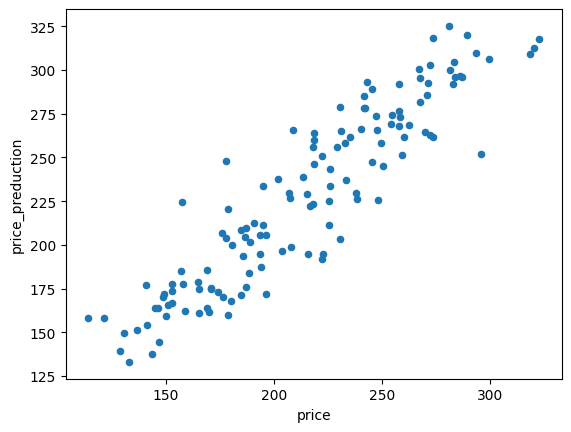

In [49]:
result.plot(kind='scatter',x='price',y='price_preduction')

In [60]:
MeanSqu_error=pow(result['price']-result['price_preduction'],2).mean()
print(f'Mean Squared Error:{MeanSqu_error}')
print(f'Root Mean Squared Error:{pow(MeanSqu_error,0.5)}')

Mean Squared Error:591.5831953050828
Root Mean Squared Error:24.322483329320686
